# To Run in Order

In [1]:
# Define your path:
#chosenPath = "/Users/nihao/Dropbox/Projects/"
chosenPath = "/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/"

# Decide your angle:
theta1 = 0.0  # [deg] rotation angles for the two layers
#theta2 = 21.787  # [deg] rotation angles for the two layers
theta2 = 9.43  # [deg] rotation angles for the two layers

# Make the unit cell

In [32]:
import math
import pybinding as pb
import numpy as np
import copy

from scipy.spatial import cKDTree
from math import pi, sin, cos, sqrt
from pybinding.repository.graphene import a_cc, a

import os
os.chdir(chosenPath)

c0 = 0.335  # [nm] graphene interlayer spacing


def unit_cell(l1, l2):
    """Make the shape of a unit cell

    Parametersi
    ----------
    l1, l2 : Tuple[float, float, float]
        Unit cell vectors.
    """

    A = np.array([0., 0.])
    B = np.array([l1[0], l1[1]])
    C = np.array([l1[0] + l2[0], l1[1] + l2[1]])
    D = np.array([l2[0], l2[1]])

    return pb.Polygon([A, B, C, D])


def add_one_atomic_layer(name, position, onsite_energy, a1, a2, shape):
    """Add a layer made from single sublattice

    Parameters
    ----------

    name : str
        User friendly name for the sublattice.
    position : Tuple[float, float, float]
        Position in xyz coordinates.
    onsite_energy : float
        Onsite energy terms at the sublattice.
    a1, a2 : Tuple[float, float, float]
        Unit cell vectors.
    shape:
        Shape of the structure (unit cell).

    Returns
    -------

    Lattice site positions. Named tuple with x, y, z fields, each a 1D array.
    """

    @pb.site_generator(name, onsite_energy)
    def define_layer():
        lat = pb.Lattice(a1=a1, a2=a2)

        lat.add_sublattices((name, position, onsite_energy))

        model = pb.Model(
            lat,
            shape,
        )

        return model.system.positions

    return define_layer


def monolayer_gr(onsite=(0, 0)):
    """Monolayer graphene lattice with `nearest_neighbors` hopping

    Parameters
    ----------

    onsite : Tuple[float, float]
        Onsite energy for sublattices A and B.

    Returns
    -------
    pb.Lattice
        Defined lattice object
    """

    from math import sqrt
    from pybinding.repository.graphene import a_cc, a, t

    lat = pb.Lattice(a1=[a, 0], a2=[a / 2, a / 2 * sqrt(3)])

    lat.add_sublattices(
        ('A', [0, -a_cc / 2], onsite[0]),
        ('B', [0, +a_cc / 2], onsite[1])
    )

    lat.add_hoppings(
        ([0, 0], 'A', 'B', t),
        ([1, -1], 'A', 'B', t),
        ([0, -1], 'A', 'B', t)
    )

    lat.min_neighbors = 0
    return lat


def rotation_matrix(theta):
    """Make a rotation matrix

    Parameters
    ----------

    theta : float
        Rotation angle.

    Returns
    -------
    np.matrix
        Rotation matrix 2D.
    """
    r = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return r


def find_row_and_col_intra(positions, positions_to, d_min_intra, d_max_intra):
    """ Find indexes for intralayer neighbours
    positions : np.ndarray
        Position of sites.
    positions_to : np.ndarray
        Position of sites that are being connected.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra : float, float
        Min and max distance for intralayer neighbour.

    Returns
    -------
    np.array, np.array
        Index of hopping from , index of hopping to.
    """

    def find_neigh_in_layer(layer):

        kdtree1 = cKDTree(data=positions[layer])
        kdtree2 = cKDTree(data=positions_to[layer])

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_intra, output_type='coo_matrix')
        abs_idx = np.flatnonzero(layer)

        idx = coo.data > d_min_intra
        row, col = abs_idx[coo.row[idx]], abs_idx[coo.col[idx]]
        return row, col

    z = positions[:, 2]
    layer1 = np.logical_and(z < c0 / 2, z > -c0 / 2)
    layer2 = z > c0 / 2
    layer3 = z < -c0 / 2
    row1, col1, row2, col2, row3, col3 = [], [], [], [], [], []
    if np.any(layer1):
        row1, col1 = find_neigh_in_layer(layer1)
        print("using layer1")
    if np.any(layer2):
        row2, col2 = find_neigh_in_layer(layer2)
        print("using layer2")
    if np.any(layer3):
        row3, col3 = find_neigh_in_layer(layer3)
        print("using layer3")

    row = np.concatenate((row1, row2, row3))
    col = np.concatenate((col1, col2, col3))

    return row.astype(np.int64), col.astype(np.int64)


def cut_periodic_neighbors(positions, l1, l2, d_min_intra, d_max_intra):
    """Find periodic neighbours based on the image algorithm
    Make images and find neighbours.
    No need to do +L and -L. One is enough, the other is automatically added to the lattice.

    positions : np.ndarray
        Position of sites.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra, d_min_inter, d_max_inter : float, float, float, float
        Min and max distance for intra and interlayer neighbours.

    Returns
    -------
    np.array, np.array, np.ndarray
        Index of hopping from , index of hopping to, unit cell reference index for all images, PBC.
    """
    # -l1
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0]
    positions_pbc[:, 1] -= l1[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row1, col1 = row_intra, col_intra
    pbc_cell1 = np.column_stack((-np.ones(row1.shape[0], dtype=np.int), np.zeros(row1.shape[0], dtype=np.int)))

    # -l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l2[0]
    positions_pbc[:, 1] -= l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row3, col3 = row_intra, col_intra
    pbc_cell3 = np.column_stack((np.zeros(row3.shape[0], dtype=np.int), -np.ones(row3.shape[0], dtype=np.int)))

    # -l1 - l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0] + l2[0]
    positions_pbc[:, 1] -= l1[1] + l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row5, col5 = row_intra, col_intra
    pbc_cell5 = np.column_stack((-np.ones(row5.shape[0], dtype=np.int), -np.ones(row5.shape[0], dtype=np.int)))

    # -l1 + l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0] - l2[0]
    positions_pbc[:, 1] -= l1[1] - l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row6, col6 = row_intra, col_intra
    pbc_cell6 = np.column_stack((-np.ones(row6.shape[0], dtype=np.int), np.ones(row6.shape[0], dtype=np.int)))

    row = np.concatenate((row1, row3, row5, row6))
    col = np.concatenate((col1, col3, col5, col6))
    pbc_cell = np.concatenate((pbc_cell1, pbc_cell3, pbc_cell5, pbc_cell6))

    return row, col, pbc_cell


# make a graphene lattice and extract unit cell vectors a1 and a2
lattice_gr = monolayer_gr()
a1, a2 = lattice_gr.vectors[0][0:2], lattice_gr.vectors[1][0:2]
radius = 100

desired_angle = theta2 - theta1
desired_angle_rad = desired_angle / 180 * pi
coeff = [3. * (1. - cos(desired_angle_rad)),
         3. * (1. - np.cos(desired_angle_rad)),
         0.5 * (1. - 2. * np.cos(desired_angle_rad))]
[w1, w2] = np.roots(coeff)

w = np.round(w1) if w1 > w2 else np.round(w2)

angle = math.acos((3 * w ** 2 + 3 * w + 0.5) / (3 * w ** 2 + 3 * w + 1)) * 180 / pi
print('Selected angle is {:.3f} degrees'.format(angle))

# find moire unit cell vectors
l1 = w * a1 + (w + 1) * a2
l2 = - (w + 1) * a1 + (2 * w + 1) * a2

# the difference in rotation between the layers
theta_diff = angle * pi / 180

# make a unit cell shape from vectors l1 and l2
shape = unit_cell(l1, l2)

# rotation matrix for hBN layer
rotate = rotation_matrix(theta_diff)

model = pb.Model(
    lattice_gr,
    shape,
    # add layers of B and N
    add_one_atomic_layer(name='C3',
                         position=[+ a_cc / 2 * math.sin(theta_diff), -a_cc / 2 * math.cos(theta_diff),
                                   -c0],
                         onsite_energy=0,
                         a1=rotate.dot(a1 / np.linalg.norm(a1) * a_cc * math.sqrt(3)),
                         a2=rotate.dot(a2 / np.linalg.norm(a2) * a_cc * math.sqrt(3)), shape=shape),
    add_one_atomic_layer(name='C4',
                         position=[- a_cc / 2 * math.sin(theta_diff), +a_cc / 2 * math.cos(theta_diff),
                                   -c0],
                         onsite_energy=0,
                         a1=rotate.dot(a1 / np.linalg.norm(a1) * a_cc * math.sqrt(3)),
                         a2=rotate.dot(a2 / np.linalg.norm(a2) * a_cc * math.sqrt(3)), shape=shape)
)

# get the positions and atom types
x, y, z = model.system.positions
atom_type = model.system.sublattices

# when using shape to select atoms, atoms that lie on the boundary might be left out
# (for a similar issue see the comments https://github.com/matplotlib/matplotlib/issues/9704)
# the following block removes the excess atoms from the unit cell
positions = np.column_stack((x, y, z))
row, col, pbc = cut_periodic_neighbors(positions, l1, l2, d_min_intra=-1e-2, d_max_intra=1e-2)
mask = np.ones(len(positions), dtype=bool)
mask[row] = False
positions = positions[mask]

x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
type = model.system.sublattices[mask]

# define different types for the xyz
diff_types = ['C1', 'C2', 'C3', 'C4']

num_sites = x.shape[0]

# export to .XYZ file
f = open('tblg_{val:.3f}.xyz'.format(val=angle), 'w')
f.write('{0:1d}\n'.format(num_sites))
f.write(
    'Lattice=" {R1x:.6f} {R1y:.6f} {R1z:.6f} {R2x:.6f} {R2y:.6f} {R2z:.6f} {R3x:.6f} {R3y:.6f} {R3z:.6f} # type  "\n'.format(
        R1x=10 * l1[0], R1y=10 * l1[1], R1z=10 * 0,
        R2x=10 * l2[0], R2y=10 * l2[1], R2z=10 * 0,
        R3x=10 * 0, R3y=10 * 0, R3z=10 * 1))

for lc, xc, yz, zc in zip(atom_type, x, y, z):
    f.write(diff_types[lc] + ' {0:.6f} {1:.6f} {2:.6f}\n'.format(10 * xc, 10 * yz, 10 * zc))

f.close()


Selected angle is 9.430 degrees
using layer1
using layer3
using layer1
using layer3
using layer1
using layer3
using layer1
using layer3


# Calculate Bandstructure routines

In [42]:
import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
import re
import sys

from scipy.spatial import cKDTree
from math import pi, sqrt
from pybinding.repository.graphene import a, a_cc, t

c0 = 0.335  # [nm] graphene interlayer spacing
# Constants and hopping values based on Kooshino's paper
V0_pi = t  # [eV] graphene NN intralayer hopping
V0_sigma = 0.48  # [eV] graphene NN interlayer hopping
rc = 0.614  # [nm] hopping fitting parameter
lc = 0.0265  # [nm] hopping fitting parameter
q_sigma = c0 * 22.2  # [nm] hopping fitting parameter
q_pi = a_cc * 22.2  # [nm] hopping fitting parameter
r0 = 0.184 * a  # [nm] hopping fitting parameter


def find_row_and_col_inter(positions, positions_pbc, d_min_inter, d_max_inter):
    """ Find indexes for interlayer neighbours
    positions : np.ndarray
        Position of sites.
    positions_to : np.ndarrayi
        Position of sites that are being connected.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra : float, float
        Min and max distance for interlayer neighbour.

    Returns
    -------
    np.array, np.array
        Index of hopping from , index of hopping to.
    """

    z = positions[:, 2]
    layer1 = np.logical_and(z < c0 / 2, z > -c0 / 2)
    layer2 = z > c0 / 2

    row1, col1 = [], []
    if np.logical_and(np.any(layer1), np.any(layer2)):
        kdtree1 = cKDTree(positions[layer1])
        kdtree2 = cKDTree(positions_pbc[layer2])

        abs_idx1 = np.flatnonzero(layer1)
        abs_idx2 = np.flatnonzero(layer2)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter
        row1, col1 = abs_idx1[coo.row[idx]], abs_idx2[coo.col[idx]]

    layer3 = z < -c0 / 2
    row2, col2 = [], []
    #print(layer1, layer2, layer3)
    unique, counts = np.unique(layer1, return_counts=True)
    temp1 = dict(zip(unique, counts))
    print(temp1)
    unique, counts = np.unique(layer3, return_counts=True)
    temp3 = dict(zip(unique, counts))
    print(temp3)

    if np.logical_and(np.any(layer1), np.any(layer3)):
        kdtree1 = cKDTree(positions[layer1])
        kdtree2 = cKDTree(positions_pbc[layer3])

        abs_idx1 = np.flatnonzero(layer1)
        abs_idx2 = np.flatnonzero(layer3)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter
        row2, col2 = abs_idx1[coo.row[idx]], abs_idx2[coo.col[idx]]

    return np.array(np.concatenate((row1, row2))).astype(np.int64), np.array(np.concatenate((col1, col2))).astype(
        np.int64)


def find_row_and_col_inter_pbc(positions, positions_pbc, d_min_inter, d_max_inter):
    """ Find indexes for interlayer neighbours
    positions : np.ndarray
        Position of sites.
    positions_to : np.ndarray
        Position of sites that are being connected.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra : float, float
        Min and max distance for interlayer neighbour.

    Returns
    -------
    np.array, np.array
        Index of hopping from , index of hopping to.
    """

    z = positions[:, 2]
    layer1 = np.logical_and(z < c0 / 2, z > -c0 / 2)
    layer2 = z > c0 / 2

    row1, col1 = [], []
    if np.logical_and(np.any(layer1), np.any(layer2)):
        kdtree1 = cKDTree(positions[layer1])
        kdtree2 = cKDTree(positions_pbc[layer2])

        abs_idx1 = np.flatnonzero(layer1)
        abs_idx2 = np.flatnonzero(layer2)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter
        row, col = abs_idx1[coo.row[idx]], abs_idx2[coo.col[idx]]

        kdtree1 = cKDTree(positions[layer2])
        kdtree2 = cKDTree(positions_pbc[layer1])

        abs_idx1 = np.flatnonzero(layer2)
        abs_idx2 = np.flatnonzero(layer1)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter
        row_inv_lay = abs_idx1[coo.row[idx]]
        col_inv_lay = abs_idx2[coo.col[idx]]

        row1 = np.append(row, row_inv_lay)
        col1 = np.append(col, col_inv_lay)

    layer3 = z < -c0 / 2
    row2, col2 = [], []

    if np.logical_and(np.any(layer1), np.any(layer3)):
        kdtree1 = cKDTree(positions[layer1])
        kdtree2 = cKDTree(positions_pbc[layer3])

        abs_idx1 = np.flatnonzero(layer1)
        abs_idx2 = np.flatnonzero(layer3)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter
        row, col = abs_idx1[coo.row[idx]], abs_idx2[coo.col[idx]]

        kdtree1 = cKDTree(positions[layer3])
        kdtree2 = cKDTree(positions_pbc[layer1])

        abs_idx1 = np.flatnonzero(layer3)
        abs_idx2 = np.flatnonzero(layer1)

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_inter, output_type='coo_matrix')

        idx = coo.data > d_min_inter

        row_inv_lay = abs_idx1[coo.row[idx]]
        col_inv_lay = abs_idx2[coo.col[idx]]

        row2 = np.append(row, row_inv_lay)
        col2 = np.append(col, col_inv_lay)

    return np.array(np.concatenate((row1, row2))).astype(np.int64), np.array(np.concatenate((col1, col2))).astype(
        np.int64)


def find_row_and_col_intra(positions, positions_to, d_min_intra, d_max_intra):
    """ Find indexes for intralayer neighbours
    positions : np.ndarray
        Position of sites.
    positions_to : np.ndarray
        Position of sites that are being connected.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra : float, float
        Min and max distance for intralayer neighbour.

    Returns
    -------
    np.array, np.array
        Index of hopping from , index of hopping to.
    """

    def find_neigh_in_layer(layer):

        kdtree1 = cKDTree(data=positions[layer])
        kdtree2 = cKDTree(data=positions_to[layer])

        coo = kdtree1.sparse_distance_matrix(kdtree2, d_max_intra, output_type='coo_matrix')
        abs_idx = np.flatnonzero(layer)

        idx = coo.data > d_min_intra
        row, col = abs_idx[coo.row[idx]], abs_idx[coo.col[idx]]
        return row, col

    z = positions[:, 2]
    layer1 = np.logical_and(z < c0 / 2, z > -c0 / 2)
    layer2 = z > c0 / 2
    layer3 = z < -c0 / 2
    row1, col1, row2, col2, row3, col3 = [], [], [], [], [], []
    if np.any(layer1):
        row1, col1 = find_neigh_in_layer(layer1)
    if np.any(layer2):
        row2, col2 = find_neigh_in_layer(layer2)
    if np.any(layer3):
        row3, col3 = find_neigh_in_layer(layer3)

    row = np.concatenate((row1, row2, row3))
    col = np.concatenate((col1, col2, col3))

    return row.astype(np.int64), col.astype(np.int64)


def periodic_neighbors(positions, l1, l2, d_min_inter, d_max_inter, d_min_intra, d_max_intra):
    """Find periodic neighbours based on the image algorithm
    Make images and find neighbours.
    No need to do +L and -L. One is enough, the other is automatically added to the lattice.

    positions : np.ndarray
        Position of sites.
    l1, l2 : np.array, np.array
        Unit cell vectors.
    d_min_intra, d_max_intra, d_min_inter, d_max_inter : float, float, float, float
        Min and max distance for intra and interlayer neighbours.

    Returns
    -------
    np.array, np.array, np.ndarray
        Index of hopping from , index of hopping to, unit cell reference index for all images, PBC.
    """

    # -l1
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0]
    positions_pbc[:, 1] -= l1[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row_inter, col_inter = find_row_and_col_inter_pbc(positions, positions_pbc, d_min_inter, d_max_inter)
    row1, col1 = np.append(row_intra, row_inter), np.append(col_intra, col_inter)
    pbc_cell1 = np.column_stack((-np.ones(row1.shape[0], dtype=np.int), np.zeros(row1.shape[0], dtype=np.int)))

    # -l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l2[0]
    positions_pbc[:, 1] -= l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row_inter, col_inter = find_row_and_col_inter_pbc(positions, positions_pbc, d_min_inter, d_max_inter)
    row3, col3 = np.append(row_intra, row_inter), np.append(col_intra, col_inter)
    pbc_cell3 = np.column_stack((np.zeros(row3.shape[0], dtype=np.int), -np.ones(row3.shape[0], dtype=np.int)))

    # -l1 - l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0] + l2[0]
    positions_pbc[:, 1] -= l1[1] + l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row_inter, col_inter = find_row_and_col_inter_pbc(positions, positions_pbc, d_min_inter, d_max_inter)
    row5, col5 = np.append(row_intra, row_inter), np.append(col_intra, col_inter)
    pbc_cell5 = np.column_stack((-np.ones(row5.shape[0], dtype=np.int), -np.ones(row5.shape[0], dtype=np.int)))

    # -l1 + l2
    positions_pbc = copy.deepcopy(positions)
    positions_pbc[:, 0] -= l1[0] - l2[0]
    positions_pbc[:, 1] -= l1[1] - l2[1]
    row_intra, col_intra = find_row_and_col_intra(positions, positions_pbc, d_min_intra, d_max_intra)
    row_inter, col_inter = find_row_and_col_inter_pbc(positions, positions_pbc, d_min_inter, d_max_inter)
    row6, col6 = np.append(row_intra, row_inter), np.append(col_intra, col_inter)
    pbc_cell6 = np.column_stack((-np.ones(row6.shape[0], dtype=np.int), np.ones(row6.shape[0], dtype=np.int)))

    row = np.concatenate((row1, row3, row5, row6))
    col = np.concatenate((col1, col3, col5, col6))
    pbc_cell = np.concatenate((pbc_cell1, pbc_cell3, pbc_cell5, pbc_cell6))

    return row, col, pbc_cell


def unit_cell_neighbours(positions, d_min_intra, d_max_intra, d_min_inter, d_max_inter):
    """Find the neighbours inside the unit cell.

    Parameters
    ----------

    positions : np.ndarray
        Position of sites.
    d_min_intra, d_max_intra, d_min_inter, d_max_inter : float, float, float, float
        Min and max distance for intra and interlayer neighbours.

    Returns
    -------
    np.array, np.array, np.ndarray
        Index of hopping from , index of hopping to, unit cell reference index
    """
    positions_to = copy.deepcopy(positions)

    # find intralayer hopping
    row_intra, col_intra = find_row_and_col_intra(positions, positions_to, d_min_intra, d_max_intra)
    # find interlayer hopping
    row_inter, col_inter = find_row_and_col_inter(positions, positions_to, d_min_inter, d_max_inter)

    row, col = np.append(row_intra, row_inter), np.append(col_intra, col_inter)
    pbc_cell = np.column_stack((np.zeros(row.shape[0], dtype=np.int), np.zeros(row.shape[0], dtype=np.int)))

    return row, col, pbc_cell


def reciprocal_vectors(l1, l2):
    """Find reciprocal vectors.

    Parameters
    ----------

    l1, l2 : np.array, np.array
        Unit cell vectors.

    Returns
    -------
    list[np.array,np.array]
        Reciprocal vectors
    """
    n = l1.shape[0]
    mat = np.column_stack((l1, l2))[:n]
    mat = 2 * pi * np.linalg.inv(mat).T
    mat = np.vstack([mat, np.zeros(shape=(3 - n, n))])
    return [v.squeeze() for v in reversed(np.hsplit(mat, n))]


def load_ovito_lattice(name):
    """Load a lattice from a Ovito .xyz file. At the moment, works for files that have following format
       Type_id X_coord Y_coord Z_coord Data
       The point needs to have all 3 coordinates, and the approach is not general.

    Parameters
    ----------

    name : str
        Name of the xyz file

    Return
    ----------

        x, y, z coordinates, atom types and l1, l2, l3 unit cell vectors
    """
    #__location__ = os.path.realpath(os.path.join(os.getcwd(), os.path.dirname(__file__)))
    #__location__ = os.path.realpath(os.path.join(os.getcwd(), os.path.dirname(.)))
    #__location__ = "/Users/nihao/Dropbox/Projects/Nicolas/bilayerSrivani/"
    __location__ = chosenPath
    #__location__ = "/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/"
    print(__location__)

    load_f = open(os.path.join(__location__, name), 'r')

    # read the atom number
    num_atoms = load_f.readline()
    print(num_atoms)

    # read the lattice vectors
    vectors = load_f.readline()
    vec = re.findall(r"[-+]?\d*\.*\d+", vectors)
    vec = list(map(float, vec))

    space_size = int(sqrt(len(vec)))

    _l1, _l2, _l3 = vec[0:space_size], vec[space_size:2 * space_size], vec[2 * space_size:3 * space_size]
    #print(_l1, _l2_, _l3_)

    _atom_type = []
    _x_coord = []
    _y_coord = []
    _z_coord = []
    for line in load_f:
        #print(line)
        atom = []
        for u in line.split():
            u = u.strip('\'')
            atom.append(u)
            #print(atom)
        _atom_type.append(atom[0])
        _x_coord.append(float(atom[1]) * 0.1)
        _y_coord.append(float(atom[2]) * 0.1)
        _z_coord.append(float(atom[3]) * 0.1)

    _x_coord = np.asarray(_x_coord)
    _y_coord = np.asarray(_y_coord)
    _z_coord = np.asarray(_z_coord)
    _atom_type = np.asarray(_atom_type)

    return _x_coord, _y_coord, _z_coord, _atom_type, _l1, _l2, _l3


def make_lattice(a1, a2, atom_type, positions, different_atoms, onsite_potential):
    """Import the loaded atoms to the lattice

    Parameters
    ----------

    a1, a2 : Tuple[float, float, float]
        Unit cell vectors
    atom_type : np.ndarray
        Sublattice labels.
    positions : np.ndarray
        Position of sites.
    different_atoms : list[str]
        Atom types loaded from XYZ
    onsite_potential : list[float]
        Onsite energy at each sublattice.

    Return
    ----------
        pb.Lattice lattice defined without the hopping terms

    """
    lat = pb.Lattice(a1=a1, a2=a2)
    list_atoms_sublattice = []

    count = np.zeros(len(different_atoms), dtype=int)
    sublattice_added = []
    for [i, atom] in enumerate(positions):
        if atom_type[i] in different_atoms:
            j = different_atoms.index(atom_type[i])

            list_atoms_sublattice.append((different_atoms[j] + str(count[j]), atom, onsite_potential[j]))
            sublattice_added.append(atom_type[i])

            count[j] += 1

    lat.add_sublattices(*list_atoms_sublattice)

    return lat


def make_complete_lattice(lattice, row, col, cell, hoppings):
    """Import the loaded atoms to the lattice

    Parameters
    ----------

    lattice : pb.Lattice
        Reference lattice without hopping.
    row : np.ndarray
        Hopping from index.
    col : np.ndarray
        Hopping to index.
    cell : list[[int, int, int]]
        List of reference unit cells for each hopping.
    hoppings : np.array
        Hopping terms.

    Return
    ----------
    pb.Lattice lattice defined with the hopping terms

    """

    lat = pb.Lattice(a1=lattice.vectors[0][0:2], a2=lattice.vectors[1][0:2])

    sub_alias_id = {}

    # add each sublattice
    for key, value in lattice.sublattices.items():
        sub_alias_id[value.unique_id] = key

        lat.add_one_sublattice(
            key, value.position, value.energy
        )

    # add each hopping term
    for unit_cell, hopping, r, c in zip(cell, hoppings, row, col):
        lat.add_one_hopping(
            unit_cell, sub_alias_id[r], sub_alias_id[c], hopping
        )

    lat.min_neighbors = 1
    return lat

# Koshino hopping routine

In [34]:
def calculate_hoppings(row, col, positions, cell, l1, l2):
    """Import the loaded atoms to the lattice

    Parameters
    ----------

    row : np.ndarray
        Hopping from index.
    col : np.ndarray
        Hopping to index.
    positions : np.ndarray
        Position of sites.
    cell : list[[int, int, int]]
        List of reference unit cells for each hopping.
    l1, l2 : np.array
        Unit cell vectors.
    Return
    ----------
        List of hopping terms.

    """

    x1, y1, z1 = positions[row, 0], positions[row, 1], positions[row, 2]

    x2, y2, z2 = positions[col, 0] + cell[:, 0] * l1[0] + cell[:, 1] * l2[0], \
                 positions[col, 1] + cell[:, 0] * l1[1] + cell[:, 1] * l2[1], \
                 positions[col, 2]

    dx, dy, dz = x1 - x2, y1 - y2, z1 - z2

    d = np.sqrt(np.square(dx) + np.square(dy) + np.square(dz))
    d = np.squeeze(np.asarray(d))
    dz = np.squeeze(np.asarray(dz))

    d = np.around(d, 6)

    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2

    return hopping

# Srivani hopping routine

In [5]:
def calculate_hoppings_Srivani(row, col, positions, cell, l1, l2):
    """Import the loaded atoms to the lattice

    Parameters
    ----------

    row : np.ndarray
        Hopping from index.
    col : np.ndarray
        Hopping to index.
    positions : np.ndarray
        Position of sites.
    cell : list[[int, int, int]]
        List of reference unit cells for each hopping.
    l1, l2 : np.array
        Unit cell vectors.
    Return
    ----------
        List of hopping terms.

    """
    
    
    #lambda0AB = 0.3284
    #epsilon0AB = 0.2829
    #x0AB = 0.0
    #kappa0AB = 0.7135
    #lambda3AB = 0.0196
    #epsilon3AB = 0.5781
    #x3AB = 1.1572
    #kappa3AB = 0.0
    #lambda6AB = -0.000357
    #epsilon6AB = -0.09014
    #x6AB = -0.96107
    #kappa6AB = 1.43341
    #xi0AB = epsilon0AB
    #xi3AB = epsilon3AB
    #xi6AB = epsilon6AB
    #lambda0AA = 0.3527
    #epsilon0AA = 0.3390
    #x0AA = 0.0
    #kappa0AA = 0.7339
    #lambda3AA = 0.00004345
    #epsilon3AA = 0.01274
    #x3AA = -7.083
    #kappa3AA = 0.0
    #lambda6AA = -0.009137
    #epsilon6AA = 0.723900
    #x6AA = 3.315000
    #kappa6AA = 0.79420
    #xi0AA = epsilon0AA
    #xi3AA = epsilon3AA
    #xi6AA = epsilon6AA
    
    g0 = -2.4389777651302801
    dd = 3.2

    if (dd == 3.35):
        print("Using 3.35 data")
        a1AA = 0.4012
        b1AA = -1.522
        c1AA = 3.32
        d1AA = 0.799
        
        a2AA = 3.487e-5
        b2AA = 0.3116
        c2AA = -0.4061
        
        a3AA = -0.02023
        b3AA = 0.8179
        c3AA = -3.253
        
        a1AB = 0.3519
        b1AB = -1.587
        c1AB = 3.428
        d1AB = -0.745
        
        a2AB = 0.02362
        b2AB = 0.6625
        c2AB = 1.338
        
        a3AB = -0.009794
        b3AB = 1.1
        c3AB = -3.069
    elif (dd == 3.2):
        print("Using 3.2 data")
        a1AA = 0.6071
        b1AA = -1.547
        c1AA = 3.31
        d1AA = 0.8127
        
        a2AA = 5.873e-5
        b2AA = 0.374
        c2AA = -0.3468
        
        a3AA = -0.0302
        b3AA = 0.8376
        c3AA = -3.203
        
        a1AB = 0.5252
        b1AB = -1.586
        c1AB = 3.412
        d1AB = 0.7586
        
        a2AB = 0.03728
        b2AB = 0.6683
        c2AB = 1.292
        
        a3AB = -0.01385
        b3AB = 1.182
        c3AB = -3.071
    
    x1, y1, z1 = positions[row, 0], positions[row, 1], positions[row, 2]

    x2, y2, z2 = positions[col, 0] + cell[:, 0] * l1[0] + cell[:, 1] * l2[0], \
                 positions[col, 1] + cell[:, 0] * l1[1] + cell[:, 1] * l2[1], \
                 positions[col, 2]

    dx, dy, dz = x1 - x2, y1 - y2, z1 - z2
    #print(dx)

    d = np.sqrt(np.square(dx) + np.square(dy) + np.square(dz))
    d = np.squeeze(np.asarray(d))
    dz = np.squeeze(np.asarray(dz))

    d = np.around(d, 6)
    
    dist = np.sqrt(np.square(dx) + np.square(dy))
    dist = np.squeeze(np.asarray(dist))
    dist = np.around(dist, 6)
    
    #print(dist)
    print(a)
    
    rbar = dist/a # nm/nm
    rbar = np.around(rbar, 6)
    
    theta = np.arctan(dy/dx) # range from -90 to 90 (in radians)
    theta = theta*180.0/np.pi

    
    #print(theta)
    #print(dx>0)
    theta = np.where(np.logical_and(dx>0.0, dy>0.0),abs(theta),theta)
    #if ((dx>0.0) & (dy>0.0)):
    #    theta = abs(theta)
    theta = np.where(np.logical_and(dx>0.0, 0.0>dy),270.0+abs(theta),theta)
    #elif (dx > 0.0 and 0.0>dy):
    #    theta =  270.0+abs(theta)
    theta = np.where(np.logical_and(dx<0.0, dy<0.0),180.0+abs(theta),theta)
    #elif (dx < 0.0 and dy < 0.0 ):
    #    theta = 180.0+abs(theta)
    theta = np.where(np.logical_and(0.0>dx, dy>0.0),90.0+abs(theta),theta)
    #elif (0.0>dx and dy > 0.0 ):
    #    theta =  90.0+abs(theta);
    theta = np.where(np.logical_and(dx== 0.0, dy == 0.0),0.0,theta)
    #elif (dx == 0.0 and dy == 0.0):
    #    theta =  0.0
    theta = np.where(np.logical_and(0.0 == dx, dy > 0.0),90.0, theta)
    #elif (dx == 0.0 and dy >0.0):
    #    theta = 90.0
    theta = np.where(np.logical_and(dx>0.0, dy == 0.0),0.0, theta)
    #elif (dx > 0.0 and dy == 0.0):
    #    theta = 0.0
    theta = np.where(np.logical_and(0.0 == dx, dy < 0.0),270.0, theta)
    #elif (dx == 0.0 and dy <0.0):
    #    theta = 270.0
    theta = np.where(np.logical_and(dx<0.0, dy == 0.0),180.0, theta)
    #elif (dx < 0.0 and dy == 0.0):
    #    theta = 180.0
    #print*, "theta, rbar = ", theta, rbar, aG
    #print(theta)
    theta = theta/(180.0/np.pi)
    #print(theta)
    
    print(len(rbar))
    #rbar = rbar*10

    #V0AA = lambda0AA * np.exp(-xi0AA*rbar**2.0) * np.cos(kappa0AA * rbar)
    #V3AA = lambda3AA * rbar**2.0 * np.exp(-xi3AA*(rbar-x3AA)**2.0) 
    #V6AA = lambda6AA * np.exp(-xi6AA*(rbar-x6AA)**2.0) * np.sin(kappa6AA * rbar)
    #V0AB = lambda0AB * np.exp(-xi0AB*rbar**2.0) * np.cos(kappa0AB * rbar)
    #V3AB = lambda3AB * rbar**2.0 * np.exp(-xi3AB*(rbar-x3AB)**2.0) 
    #V6AB = lambda6AB * np.exp(-xi6AB*(rbar-x6AB)**2.0) * np.sin(kappa6AB * rbar)
    V0AA = a1AA * np.exp(-((rbar-b1AA)/c1AA)**4) * np.cos(d1AA*rbar)
    V3AA = a2AA * rbar**2 *np.exp(-b2AA*(rbar-c2AA)**2)
    V6AA = a3AA * np.exp(-b3AA * (rbar + c3AA)**2)
    V0AB = a1AB * np.exp(-((rbar-b1AB)/c1AB)**4) * np.cos(d1AB*rbar)
    V3AB = a2AB * rbar**2 *np.exp(-b2AB*(rbar-c2AB)**2)
    V6AB = a3AB * np.exp(-b3AB * (rbar + c3AB)**2)
    V0 = (V0AA + V0AB)/2.0
    V3 = V3AB
    V6 = (V6AA + V6AB)/2.0
    #print*, "Vs: ", V0, V3, V6
    #if (SrivaniAA) 
    #    hopp(j,i) = -(V0AA + V3AA * cos(3.0*theta) + V6AA*cos(6.0*theta))
    #else if (SrivaniAB) then
    #    hopp(j,i) = -(V0AB + V3AB * cos(3.0*theta) + V6AB*cos(6.0*theta))
    #else
    #print(V0)
    acc = a/np.sqrt(3)
    #print(dist)
    #print(acc)
    #print(np.logical_and(dist > 0.99 * acc, dist < 1.01*acc))
    hopping = np.where(abs(dz) > 0.1, -(V0 + V3 * np.cos(3.0*theta) + V6*np.cos(6.0*theta)), 0)
    #print(hopping)
    hopping = np.where(np.logical_and(np.logical_and(dist > 0.99 * acc, dist < 1.01*acc),abs(dz) < 0.01), g0, hopping)
    #print(hopping)
    #end if

    

    #v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    #v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
#
    #hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2

    np.set_printoptions(threshold=np.inf)
    #np.set_printoptions(threshold=1000)
    #print(hopping)
    return hopping

# Bandstructures

## Srivani

/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/
148

Using 3.2 data
0.24595
22439


/Users/nihao/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:136: RuntimeWarning: divide by zero encountered in true_divide


Done in:  4.27s


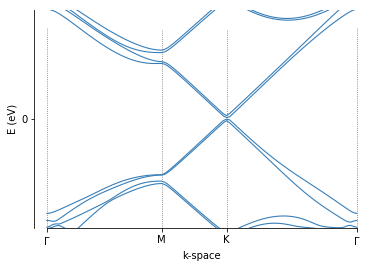

In [6]:
#angle = 9.43
name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd

# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
different_atoms = ['C1', 'C2', 'C3', 'C4']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)

# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings_Srivani(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.25,1.25)
plt.show()

/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/
148

Using 3.2 data
0.24595
22439


/Users/nihao/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:136: RuntimeWarning: divide by zero encountered in true_divide


Done in:  4.28s


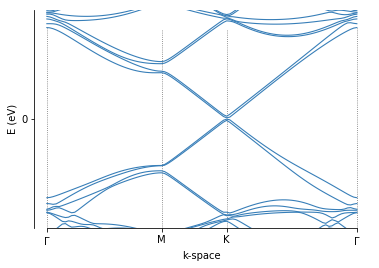

In [7]:
os.chdir("/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/")

#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd
name = 'tblg_9.430_sameC.xyz'

# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
#different_atoms = ['C1', 'C2', 'C3', 'C4']
different_atoms = ['C']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)

# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings_Srivani(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.5,1.5)
plt.show()

## Koshino

/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle6.01/2D/biggerCell/
148

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False] [

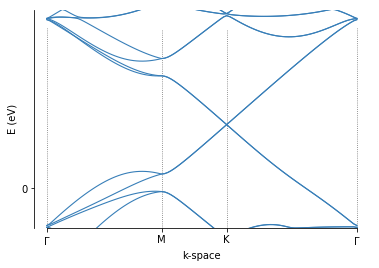

In [35]:
#angle = 9.43
name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd




# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
different_atoms = ['C1', 'C2', 'C3', 'C4']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)

# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.25+0.75,1.25+1)
plt.show()

# Play with LAMMPs output

/Users/nihao/Dropbox/nonSharedProjectsFolders/bilayerSrivani/
148

Done in:  4.29s


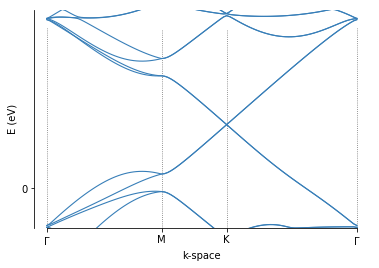

In [9]:
#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd

os.chdir("")

#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd
name = 'tblg_9.430_sameC.xyz'

# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
different_atoms = ['C']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)

# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.25+0.75,1.25+1)
plt.show()

In [29]:
norm = np.sqrt(19.680000000**2 + 12.782534960**2)
print(norm)


norm = np.sqrt((-1.230000000)**2 + 23.434647426**2)
print(norm)

-1.08/norm

19.53/19.68

23.46690435493404
23.466904354450513


0.9923780487804879

## 6.01.xyz

/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle6.01/2D/biggerCell/
   364

{False: 176, True: 188}
{False: 188, True: 176}
Done in:  17.5s


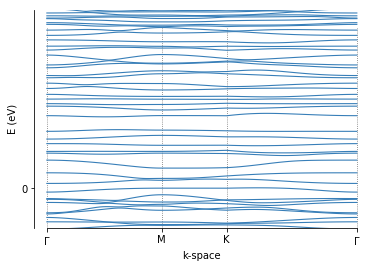

In [48]:
#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd

chosenPath = "/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle6.01/2D/biggerCell/"
#os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle_3.48/usingLatticePositions/")

#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd
#name = 'angle3_48.xyz'
name = "unitCell.xyz"

# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

#print(positions)

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
different_atoms = ['C']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)


# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.25+0.75,1.25+1)
plt.show()

/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle6.01/2D/biggerCell/
   364

{False: 182, True: 182}
{False: 182, True: 182}
Done in:  9.22s


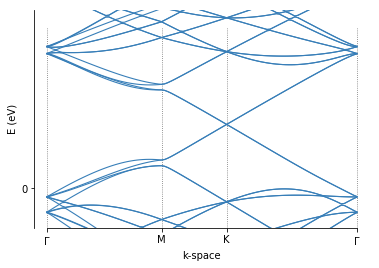

In [45]:
#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd

chosenPath = "/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle6.01/2D/biggerCell/"
#os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/LAMMPS/bilayerGrapheneLAMMPS/Angle_3.48/usingLatticePositions/")

#angle = 9.43
#name = 'tblg_{:.3f}.xyz'.format(angle)
#name = 'pos.xyz'
#%pwd
#name = 'angle3_48.xyz'
name = "inputInitShifted.xyz"

# load coordinates, atom types and lattice vectors
x_coord, y_coord, z_coord, atom_type, l1, l2, l3 = load_ovito_lattice(name)
#print(x_coord, y_coord, z_coord, atom_type, l1, l2, l3)
l1 = np.array(l1[0:2]) / 10.
l2 = np.array(l2[0:2]) / 10.
positions = np.column_stack((x_coord, y_coord, z_coord))

#print(positions)

# name for different sublattices, still every added atom to the model needs to have a different sublattice ID,
# and this is where the sublattice info is lost
different_atoms = ['C']
# different_atoms = ['0', '1', '2', '3']

# onsite potential in this case between layers
onsite_potential = [0, 0, 0, 0]

# min and max interlayer radius for neighbour search
d_min_intra, d_max_intra = 0.99 * a_cc, 8 * a_cc
# min and max intralayer radius for neighbour search
d_min_inter, d_max_inter = 0.98 * c0, 8 * a_cc

# make a lattice without hopping
lattice = make_lattice(l1, l2, atom_type, positions, different_atoms, onsite_potential)


# find periodic hopping
row_pbc, col_pbc, cell_pbc = periodic_neighbors(positions, l1=l1, l2=l2,
                                                d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                d_min_intra=d_min_intra, d_max_intra=d_max_intra)
# find hopping inside the unit cell
row_unit, col_unit, cell_unit = unit_cell_neighbours(positions, d_min_inter=d_min_inter, d_max_inter=d_max_inter,
                                                     d_min_intra=d_min_intra, d_max_intra=d_max_intra)

# for hopping i, j (i < j) conjugated hopping (j, i) is added automatically. (i, i) needs to be added as a onsite energy
# not a hopping.
row_unit, col_unit, cell_unit = row_unit[row_unit < col_unit], col_unit[row_unit < col_unit], \
                                cell_unit[row_unit < col_unit]

row = np.concatenate((row_pbc, row_unit))
col = np.concatenate((col_pbc, col_unit))
cell = np.concatenate((cell_pbc, cell_unit))

# number of unit cells in a1 and a2 direction
num_a1, num_a2 = 1, 1

# calculate the hoppings based on the distance
hoppings = calculate_hoppings(row, col, positions, cell, l1, l2)
# make a full pb.Lattice with sites and hoppings
complete_lattice = make_complete_lattice(lattice, row, col, cell, hoppings)
# save the lattice
pb.save(complete_lattice, 'lattice_' + name[:-4])

# reciprocal vectors, defining a grid
b1, b2 = reciprocal_vectors(num_a1 * l1, num_a2 * l2)

model = pb.Model(complete_lattice,
                 pb.translational_symmetry(True, True),
                 )
pb.utils.tic()
num_points = 100
step = np.linalg.norm(b1) / num_points
# define a specific path
k11 = 1 / 3 * b1[0:2] + 2 / 3 * b2[0:2]
k21 = 2 / 3 * b1[0:2] + 1 / 3 * b2[0:2]
mp = (k11 + k21) / 2
# k_path doesn't allow specifying number of points only allows setting the step
points = [[0, 0], mp, k11, [0, 0]]
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)
# change the number of points to num_points
step = step * k_path.shape[0] / num_points
k_path = pb.make_path([0, 0], mp, k11, [0, 0], step=step)



solver = pb.solver.lapack(model)
bands = solver.calc_bands(*points, step=step)
bands.plot(['$\Gamma$', 'M', 'K', '$\Gamma$'])#,linestyle='None', marker="*")

pb.utils.toc("Done in: ")

plt.ylim(-1.25+0.75,1.25+1)
plt.show()